In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
sweep_columns = ['GAIA_PHOT_G_MEAN_MAG', 'GAIA_PHOT_BP_MEAN_MAG', 'GAIA_PHOT_RP_MEAN_MAG', 'GAIA_ASTROMETRIC_EXCESS_NOISE', 'FITBITS']

cat0 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_north_0.49.0_basic.fits', ))
cat = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_north_0.49.0_photom.fits', ))
cat1 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_north_0.49.0_more_1.fits', columns=sweep_columns))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

10978643


In [31]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

In [5]:
mask = cat['MORPHTYPE']=='PSF'
print(np.sum(mask)/len(cat))

0.08053372352120385


In [7]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))

0.014884444279680102


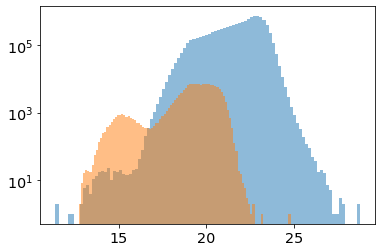

In [8]:
plt.hist(cat['rmag'][~mask], 100, log=True, alpha=0.5)
plt.hist(cat['rmag'][mask], 100, log=True, alpha=0.5)
plt.show()

In [9]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
cat['GAIA_PHOT_G_MEAN_MAG'][mask].min()

13.000337

0.014884444279680102


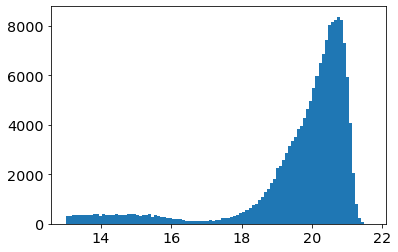

In [10]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100)
plt.show()

0.014884444279680102


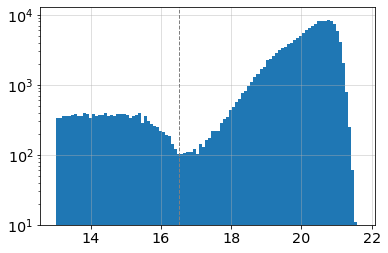

In [11]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True)
plt.grid(alpha=0.5)
plt.ylim(ymin=10)
plt.axvline(16.5, ls='--', lw=1, color='gray')
plt.show()

0.014884444279680102


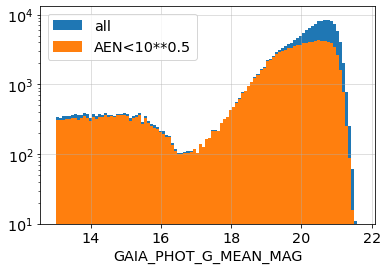

In [40]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))
mask1 = mask & (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True, label='all')
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask1], 100, log=True, label='AEN<10**0.5')
plt.grid(alpha=0.5)
plt.ylim(ymin=10)
# plt.axvline(16.5, ls='--', lw=1, color='gray')
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.legend()
plt.show()

In [14]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<16.)
print(np.sum(mask)/len(cat))

0.0010987696749042665


In [23]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']>16)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<16.5)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection1.txt', format='ascii.no_header', overwrite=True)

960
943


In [22]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']>16.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<17.)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection2.txt', format='ascii.no_header', overwrite=True)

625
613


In [26]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']>17)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<17.5)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection3.txt', format='ascii.no_header', overwrite=True)

897
889


In [27]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']>17.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<18.)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection4.txt', format='ascii.no_header', overwrite=True)

1700
1688


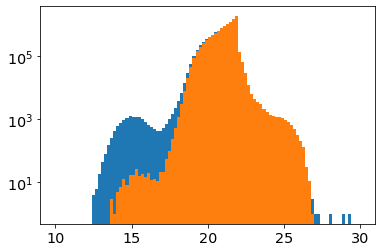

In [43]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['zfibermag'], 100, log=True, range=(10, 30))
plt.hist(cat['zfibermag'][~mask], 100, log=True, range=(10, 30))
plt.show()

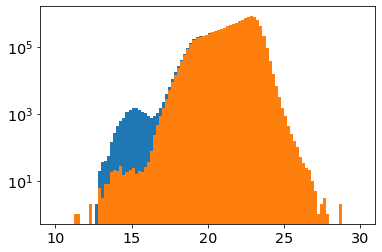

In [42]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['rmag'], 100, log=True, range=(10, 30))
plt.hist(cat['rmag'][~mask], 100, log=True, range=(10, 30))
plt.show()

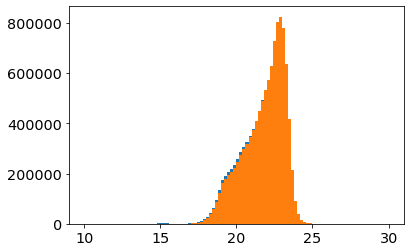

In [44]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['rmag'], 100, log=False, range=(10, 30))
plt.hist(cat['rmag'][~mask], 100, log=False, range=(10, 30))
plt.show()

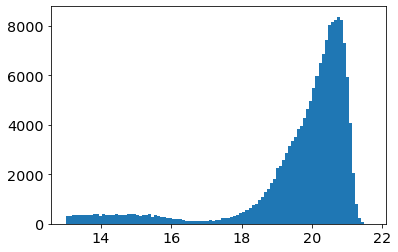

In [41]:
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100);